In [1]:
import pandas as pd

In [2]:
kyphosis_df=pd.read_csv('./kyphosis.csv')

In [3]:
kyphosis_df.head(3)

,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14
2,present,128,4,5


In [4]:
kyphosis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Kyphosis  81 non-null     object
 1   Age       81 non-null     int64 
 2   Number    81 non-null     int64 
 3   Start     81 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 2.7+ KB


In [5]:
kyphosis_df.describe()

,Age,Number,Start
count,81.000000,81.000000,81.000000
mean,83.654321,4.049383,11.493827
std,58.104251,1.619423,4.883962
min,1.000000,2.000000,1.000000
25%,26.000000,3.000000,9.000000
50%,87.000000,4.000000,13.000000
75%,130.000000,5.000000,16.000000
max,206.000000,10.000000,18.000000


In [6]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

LocalEncoder=LabelEncoder()
kyphosis_df['Kyphosis']=LocalEncoder.fit_transform(kyphosis_df['Kyphosis'])


In [7]:
kyphosis_df.head(3)

,Kyphosis,Age,Number,Start
0,0,71,3,5
1,0,158,3,14
2,1,128,4,5


In [8]:
kyphosis_true=kyphosis_df[kyphosis_df['Kyphosis']==1]
kyphosis_false=kyphosis_df[kyphosis_df['Kyphosis']==0]

In [9]:
print('disease percentage in dataset: ',(len(kyphosis_true)/len(kyphosis_df))*100)

disease percentage in dataset:  20.98765432098765


<Axes: >

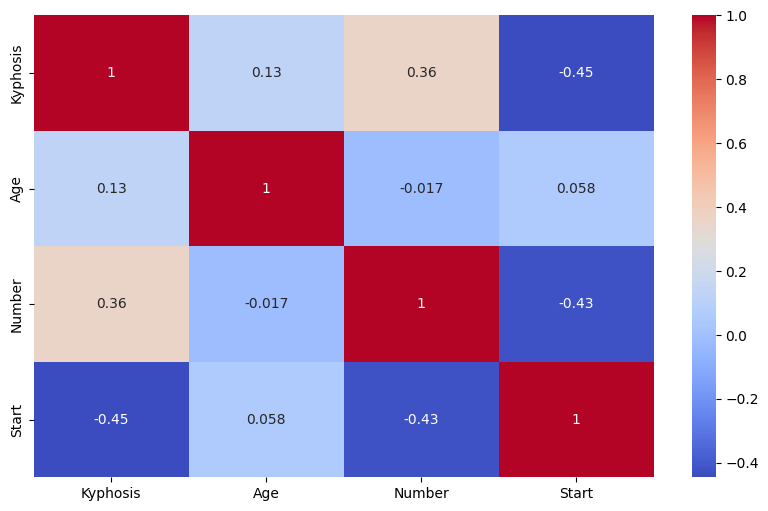

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(kyphosis_df.corr(),annot=True,cmap='coolwarm')

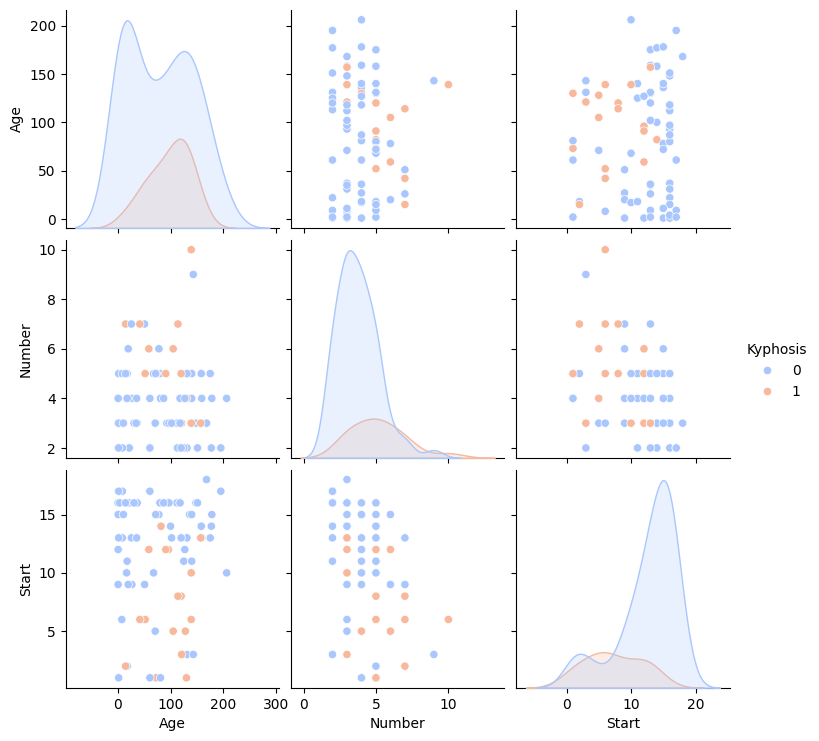

In [11]:
sns.pairplot(kyphosis_df,hue='Kyphosis',palette='coolwarm')

C:\Users\madam\AppData\Local\Temp\ipykernel_11188\3770074820.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Kyphosis',data=kyphosis_df,palette='coolwarm')


<Axes: xlabel='Kyphosis', ylabel='count'>

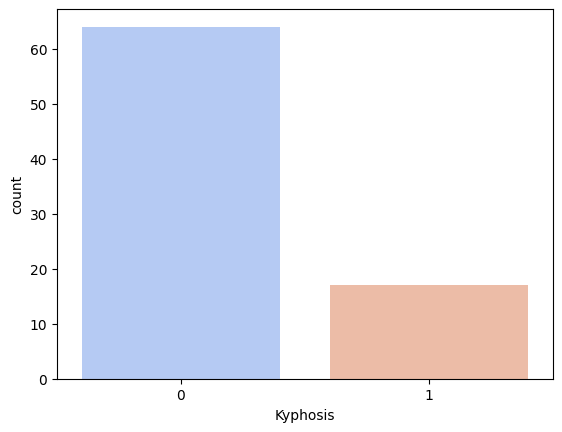

In [12]:
sns.countplot(x='Kyphosis',data=kyphosis_df,palette='coolwarm')

In [13]:
X = kyphosis_df.drop('Kyphosis',axis=1)
y = kyphosis_df['Kyphosis']

In [14]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=101)

In [15]:
from sklearn.linear_model import LogisticRegression

model=LogisticRegression()
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [16]:
y_predict_test=model.predict(X_test)

<Axes: >

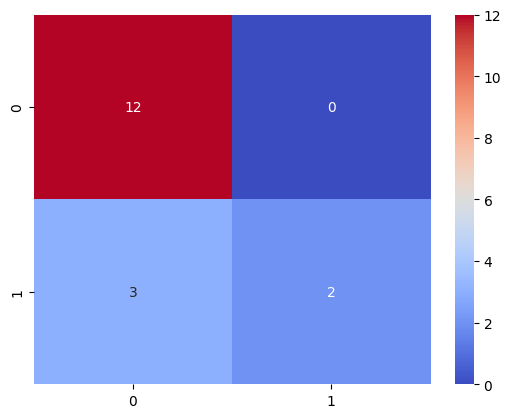

In [17]:
from sklearn.metrics import classification_report,confusion_matrix
cm=confusion_matrix(y_test,y_predict_test)
sns.heatmap(cm,annot=True,cmap='coolwarm',fmt='d')

In [18]:
print(classification_report(y_test,y_predict_test))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89        12
           1       1.00      0.40      0.57         5

    accuracy                           0.82        17
   macro avg       0.90      0.70      0.73        17
weighted avg       0.86      0.82      0.80        17



<Axes: >

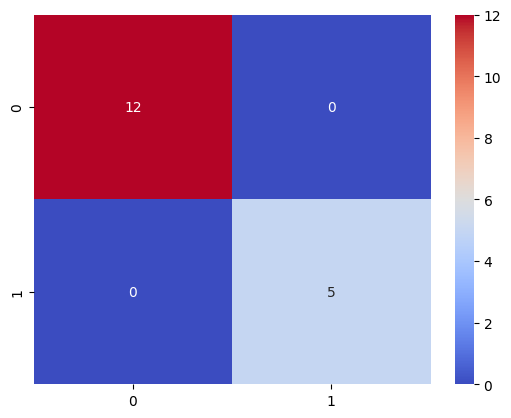

In [24]:
from sklearn.tree import DecisionTreeClassifier

dtree=DecisionTreeClassifier()
dtree.fit(X_train,y_train)
# dtree.predict(X_test)
y_predict_dtree=dtree.predict(X_test)
cm_dtree=confusion_matrix(y_test,y_predict_dtree)
sns.heatmap(cm_dtree,annot=True,cmap='coolwarm',fmt='d')


In [29]:
feature_importances=pd.DataFrame(dtree.feature_importances_,index=X_train.columns,columns=['importance']).sort_values('importance',ascending=False)
feature_importances

,importance
Age,0.507018
Start,0.390418
Number,0.102564


In [33]:
from sklearn.tree import export_text

tree_rules = export_text(dtree, feature_names=list(X_train.columns))
print(tree_rules)

|--- Start <= 8.50
|   |--- Age <= 11.50
|   |   |--- class: 0
|   |--- Age >  11.50
|   |   |--- Start <= 5.50
|   |   |   |--- Age <= 16.50
|   |   |   |   |--- class: 1
|   |   |   |--- Age >  16.50
|   |   |   |   |--- Age <= 72.00
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Age >  72.00
|   |   |   |   |   |--- Age <= 130.50
|   |   |   |   |   |   |--- Age <= 101.00
|   |   |   |   |   |   |   |--- Number <= 4.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- Number >  4.50
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- Age >  101.00
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- Age >  130.50
|   |   |   |   |   |   |--- class: 0
|   |   |--- Start >  5.50
|   |   |   |--- class: 1
|--- Start >  8.50
|   |--- Start <= 14.50
|   |   |--- Age <= 55.00
|   |   |   |--- class: 0
|   |   |--- Age >  55.00
|   |   |   |--- Age <= 96.50
|   |   |   |   |--- Start <= 11.00
|   |   |   |   |   |---

<Axes: >

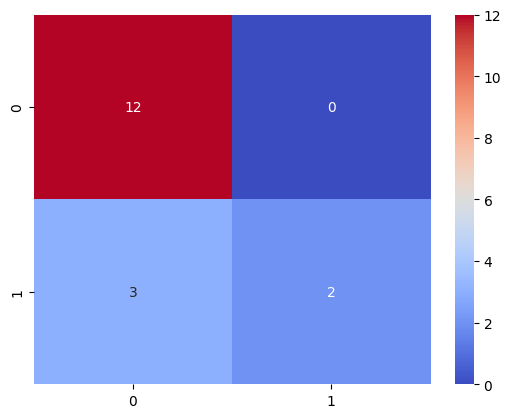

In [34]:
from sklearn.ensemble import RandomForestClassifier

rfc=RandomForestClassifier(n_estimators=100)
rfc.fit(X_train,y_train)    
y_predict_rfc=rfc.predict(X_test)
cm_rfc=confusion_matrix(y_test,y_predict_rfc)   
sns.heatmap(cm_rfc,annot=True,cmap='coolwarm',fmt='d')
